# ex-7 — six-factor model: rotation and identification across the spectrum

The ex-6 machinery on a **6-factor** model calibrated to stylized real-data magnitudes —
factor vols ordered like a typical equity style stack, with adjacent spike gaps ranging
from comfortable to nearly degenerate, so the identification behavior seen in the 3-factor
pair now plays out at several points along the spectrum at once.

| j | stylized name | vol | $\rho_j = c_j\sigma_j^2$ | $\rho_j/\rho_{j+1}$ |
|---|---|---|---|---|
| 1 | Market  | 16.0% | 0.0320 | 3.20 |
| 2 | Value   | 10.0% | 0.0100 | 1.56 |
| 3 | Size    |  8.0% | 0.0064 | 1.51 |
| 4 | Momentum|  6.5% | 0.0042 | **1.17** |
| 5 | Quality |  6.0% | 0.0036 | 2.25 |
| 6 | LowVol  |  4.0% | 0.0016 | — |

(Levels are stylized, not fitted — chosen so the 4–5 pair is deeply degenerate, 2–3 and
3–4 marginal, and 1–2 / 5–6 comfortable. Market keeps $c_1 = 1.25$ via the $\beta$ mean;
other prevalences are 1.)

Route: record coordinates (classes carried from ex-6, already $k$-generic) → run/load the
$n$-sweep at $p{=}3000$ → derive + verify → scalar overview across all six factors →
**successive factor-pair planes** with overlaid clouds and mean arrows. Factor coloring is
consistent throughout: 1 blue, 2 orange, 3 green, 4 red, 5 purple, 6 brown.

In [1]:
import sys
from io import BytesIO
from pathlib import Path

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from loguru import logger
logger.remove()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from fl_experiment_setup import ModelSpec, DesignSpec
from fl_experiment_runner import run_experiment
from fl_plot import grid, Row, BoxDist, RefOverlay, DiskDensity, THEME

DATA_DIR = REPO_ROOT / "nb_outputs"
OUT_DIR = DATA_DIR / "ex-7_six_factor"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_FORMATS = ("png", "pdf")   # the disk (radial) figures save in each format


def show(fig):
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    display(Image(data=buf.getvalue()))
    plt.close(fig)


K = 6
VOLS = [0.16, 0.10, 0.08, 0.065, 0.06, 0.04]
NAMES = ["Market", "Value", "Size", "Momentum", "Quality", "LowVol"]

model = ModelSpec(
    k_factors=K,
    factor_vols=VOLS,
    beta_samplers=[{"distribution": "normal", "loc": 1.0, "scale": 0.5}]
                  + [{"distribution": "normal", "loc": 0.0, "scale": 1.0}] * (K - 1),
    idio_vol_sampler={"distribution": "constant", "value": 0.4},
)
HEAVY_TAIL = dict(
    factor_return_sampler={"distribution": "student_t", "df": 6, "loc": 0.0, "scale": 1.0},
    idio_return_sampler={"distribution": "student_t", "df": 5, "loc": 0.0, "scale": 1.0},
)
N_REPS, SEED = 600, 20260511
_TAILS = r"(Factor Returns ~ $\mathcal{T}_6$, Idiosyncratic Returns ~ $\mathcal{T}_5$)"

rho = np.array([1.25] + [1.0] * (K - 1)) * np.array(VOLS) ** 2
print("rho:", np.round(rho, 5))
print("adjacent ratios:", np.round(rho[:-1] / rho[1:], 2))

rho: [0.032   0.01    0.0064  0.00423 0.0036  0.0016 ]
adjacent ratios: [3.2  1.56 1.51 1.17 2.25]


## Step 1–2 — record + sweeps

Classes carried verbatim from ex-6 — `record()` already loops over $k$, so nothing changes
for six factors: `hb1..hb6` (coordinates of $\Pi h_j$ in the $b$-basis) and `nu1..nu6`
(components of $\hat\nu_j$) per replicate and factor. Two sweeps, $R = 600$ each, cached
to `ex7_df_{n,p}.parquet`:

* **growing n** at $p{=}3000$ — $n \in \{20, 63, 250\}$: the axis that resolves
  identification;
* **growing p** at $n{=}63$ — $p \in \{100, \dots, 50{,}000\}$: the axis that removes the
  finite-$p$ elevation but cannot fix the finite-$n$ rotation.


In [2]:
from sim_theorem_partii import Eq6RHSAnalysis
from factor_lab.analyses.spectral import compute_true_eigenvalues
from factor_lab.analyses import compute_sine_alignment
from fl_experiment_setup import BaseExperiment


class Eq6RHSWithNu(Eq6RHSAnalysis):
    """Eq6RHSAnalysis plus the eigenvector coordinates of the k×k realized Gram."""

    def analyze(self, context) -> dict:
        result = super().analyze(context)
        k, n = context.k, context.T
        F = context.factor_returns.T
        if self.center:
            F = F - F.mean(axis=1, keepdims=True)
        c_half = np.sqrt((context.model.B ** 2).mean(axis=1))
        D_hat = (c_half[:, None] * (F @ F.T / n)) * c_half[None, :]
        vals, vecs = np.linalg.eigh(D_hat)
        result["nu_coords"] = vecs[:, np.argsort(vals)[::-1]]
        return result


class ProjectedSpectrumAnalysis:
    """Dual-Gram PCA with the finite-p split AND the raw projection coordinates."""

    def __init__(self, population_loading_directions_b_pop, center: bool = True):
        self.population_loading_directions_b_pop = population_loading_directions_b_pop
        self.center = center

    def analyze(self, context) -> dict:
        k = context.k
        Y = context.security_returns.T
        if self.center:
            Y = Y - Y.mean(axis=1, keepdims=True)
        G = Y.T @ Y
        eigenvalues, eigenvectors = np.linalg.eigh(G)
        top_k = np.argsort(eigenvalues)[::-1][:k]
        sv = np.sqrt(np.maximum(eigenvalues[top_k], 0.0))
        H = (Y @ eigenvectors[:, top_k]) / np.where(sv > 1e-14, sv, 1.0)
        sin2_angle, _ = compute_sine_alignment(
            self.population_loading_directions_b_pop, H.T)
        coeffs = self.population_loading_directions_b_pop @ H
        in_subspace = (coeffs ** 2).sum(axis=0)
        return {"sin2_j": sin2_angle,
                "measured_out_of_subspace": 1.0 - in_subspace,
                "h_coords": coeffs}


class InSubRotationExperiment(BaseExperiment):
    def __init__(self, center: bool = True):
        self.center = center

    def cell_setup(self, model, n: int, p: int):
        _, b_pop = compute_true_eigenvalues(model, model.k)
        return [ProjectedSpectrumAnalysis(b_pop, center=self.center),
                Eq6RHSWithNu(center=self.center)]

    def record(self, n: int, p: int, merged: dict) -> list[dict]:
        k = len(merged["sin2_j"])
        C, W = merged["h_coords"], merged["nu_coords"]
        return [{
            "n": n, "p": p, "j": j + 1,
            "sin2_j": float(merged["sin2_j"][j]),
            "rhs": float(merged["rhs"][j]), "floor": float(merged["floor"][j]),
            "rotation": float(merged["rotation"][j]),
            "measured_out_of_subspace": float(merged["measured_out_of_subspace"][j]),
            **{f"hb{i + 1}": float(C[i, j]) for i in range(k)},
            **{f"nu{i + 1}": float(W[i, j]) for i in range(k)},
        } for j in range(k)]


design_n = DesignSpec(
    n_values=[20, 63, 250], p_values=[3000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)
design_p = DesignSpec(
    n_values=[63], p_values=[100, 500, 5000, 10000, 20000, 50000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)

_REQ = {f"hb{i}" for i in range(1, K + 1)} | {f"nu{i}" for i in range(1, K + 1)}


def load_or_run(path, design, label):
    if path.exists():
        d = pd.read_parquet(path)
        if (_REQ <= set(d.columns)
                and sorted(d["n"].unique()) == sorted(design.n_values)
                and sorted(d["p"].unique()) == sorted(design.p_values)
                and int(d.groupby(["n", "p", "j"]).size().max()) == design.n_reps
                and d["j"].max() == K):
            print(f"{label}: loaded cached sweep {path.name} ({len(d):,} rows)")
            return d
        print(f"{label}: cache mismatch — re-running")
    d = run_experiment(model, design, InSubRotationExperiment(), progress=True)
    d.to_parquet(path)
    print(f"{label}: ran sweep ({len(d):,} rows) → {path.name}")
    return d


df_n = load_or_run(DATA_DIR / "ex7_df_n.parquet", design_n, "growing-n")
df_p = load_or_run(DATA_DIR / "ex7_df_p.parquet", design_p, "growing-p")


growing-n: loaded cached sweep ex7_df_n.parquet (10,800 rows)
growing-p: loaded cached sweep ex7_df_p.parquet (21,600 rows)


## Step 3 — derive + verify

Same derivation as ex-6, $k$-generic: in-subspace rotation from coordinates, cross-checked
against the exact-split identity; unit-normalized sign-folded disk coordinates for all six
axes.

In [3]:
HB = [f"hb{i}" for i in range(1, K + 1)]
NU = [f"nu{i}" for i in range(1, K + 1)]


def derive(df):
    C, W = df[HB].to_numpy(), df[NU].to_numpy()
    norm2 = (C ** 2).sum(axis=1)
    cjj = np.take_along_axis(C, (df["j"].to_numpy() - 1)[:, None], axis=1)[:, 0]
    sgn_h = np.sign(np.take_along_axis(C, np.abs(C).argmax(axis=1)[:, None], axis=1))[:, 0]
    sgn_nu = np.sign(np.take_along_axis(W, np.abs(W).argmax(axis=1)[:, None], axis=1))[:, 0]
    nrm = np.sqrt(norm2)
    out = df.assign(sin2_in=1.0 - cjj ** 2 / norm2)
    out = out.assign(diff_in_rot=out["sin2_in"] - df["rotation"])
    for i in range(K):
        out[f"hd{i + 1}"] = sgn_h * C[:, i] / nrm
        out[f"nud{i + 1}"] = sgn_nu * W[:, i]
    return out


df_n, df_p = derive(df_n), derive(df_p)

for nm, d in (("growing-n", df_n), ("growing-p", df_p)):
    ident = (d["sin2_j"] - d["measured_out_of_subspace"]) / (1 - d["measured_out_of_subspace"])
    print(f"{nm}: |sin2_in(coords) − sin2_in(identity)| max = "
          f"{(d['sin2_in'] - ident).abs().max():.2e};  "
          f"|‖c‖² − (1−oos)| max = "
          f"{((d[HB] ** 2).sum(axis=1) - (1 - d['measured_out_of_subspace'])).abs().max():.2e}")


growing-n: |sin2_in(coords) − sin2_in(identity)| max = 3.40e-14;  |‖c‖² − (1−oos)| max = 5.55e-17
growing-p: |sin2_in(coords) − sin2_in(identity)| max = 2.58e-14;  |‖c‖² − (1−oos)| max = 5.55e-17


## Step 4 — scalar overview: all six factors at once

In-subspace rotation distribution per factor with the $k\times k$ limit overlaid. The
spike-gap table above predicts the ordering: Market clean at every $n$; Value/Size
moderate; **Momentum and Quality (the 1.17× pair) worst**, with heavy upper tails at
$n=20$ and $63$; LowVol better than its neighbors despite the smallest vol, because its
gap to Quality is comfortable.

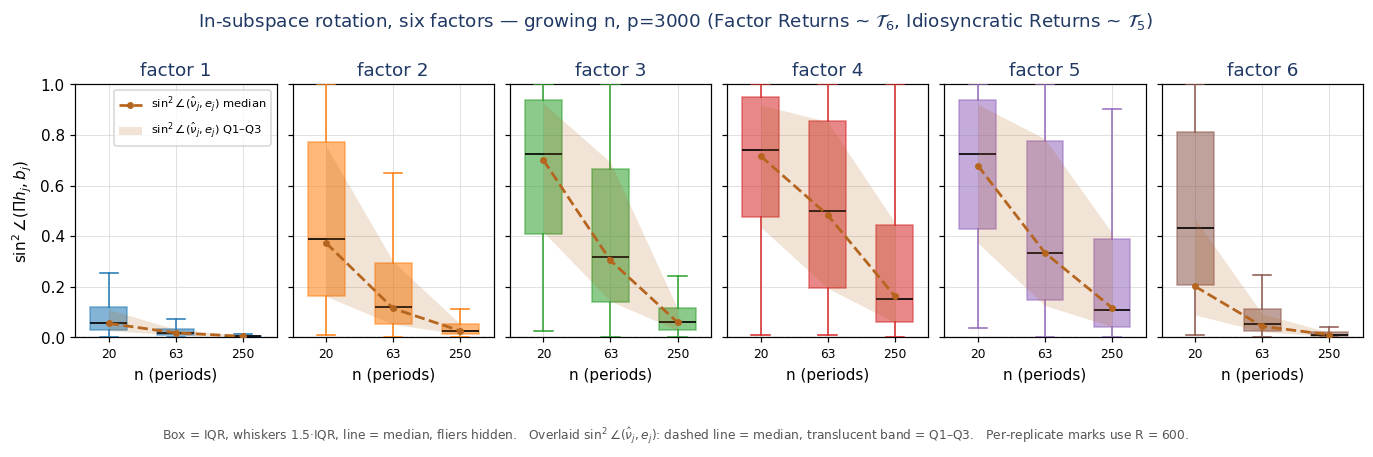

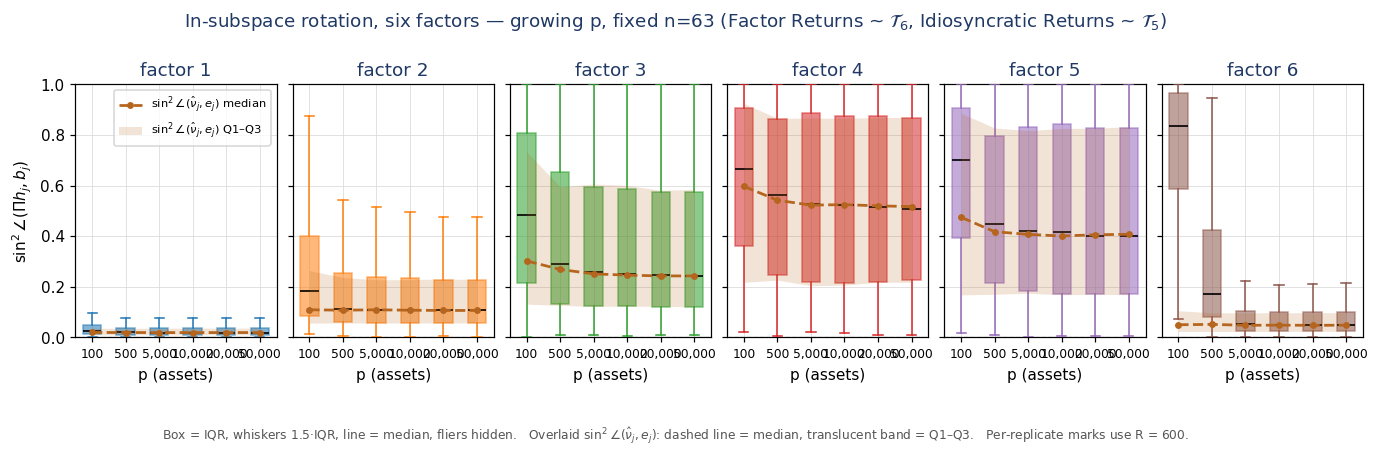

In [4]:
for df, key, lab, stem in ((df_n, "n", "growing n, p=3000", "ex7_insub_dist_n"),
                           (df_p, "p", "growing p, fixed n=63", "ex7_insub_dist_p")):
    fig, _ = grid(df, key,
                  rows=[Row([BoxDist("sin2_in"),
                             RefOverlay("rotation", label=r"$\sin^2\angle(\hat\nu_j, e_j)$")],
                            ylabel=r"$\sin^2\angle(\Pi h_j, b_j)$", ylim=(0, 1), height=1.0)],
                  sharey=True,
                  suptitle=f"In-subspace rotation, six factors — {lab} {_TAILS}",
                  out_path=OUT_DIR / stem)
    show(fig)


## Step 5 — successive factor-pair planes, both sweeps

Two figures per adjacent pair $(b_j, b_{j+1})$, both clouds overlaid with mean arrows:

* **growing n** (rows $n = 20, 63, 250$) — identification resolving as the spike gap
  sharpens; read arrow lengths as identification scores;
* **growing p** (rows $p = 100, 5000, 50000$, plus the $\hat\nu_j$ **limit clouds** in the
  $(e_j, e_{j+1})$ plane as the bottom row) — the finite-$p$ clouds tighten onto the limit
  clouds, but the limit itself keeps whatever confusion $n{=}63$ leaves: for
  Momentum–Quality the p=50,000 row and the limit row are equally smeared, the visual
  statement that more assets cannot resolve a factor-space degeneracy.


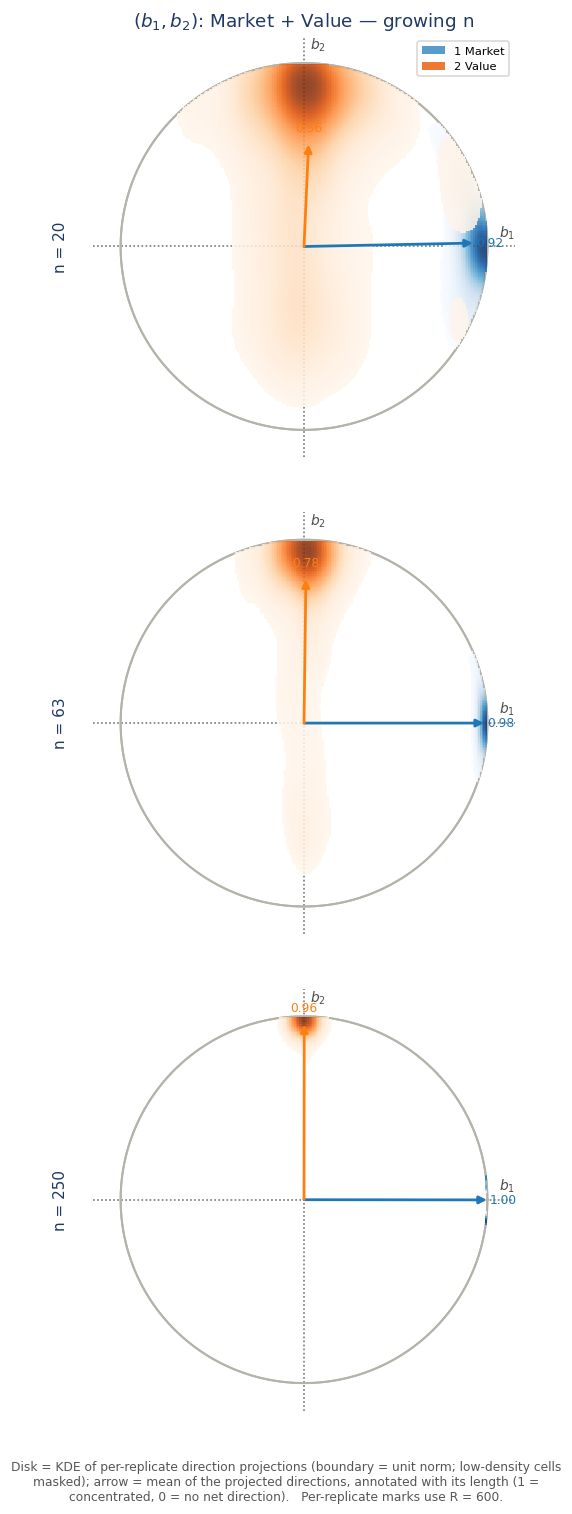

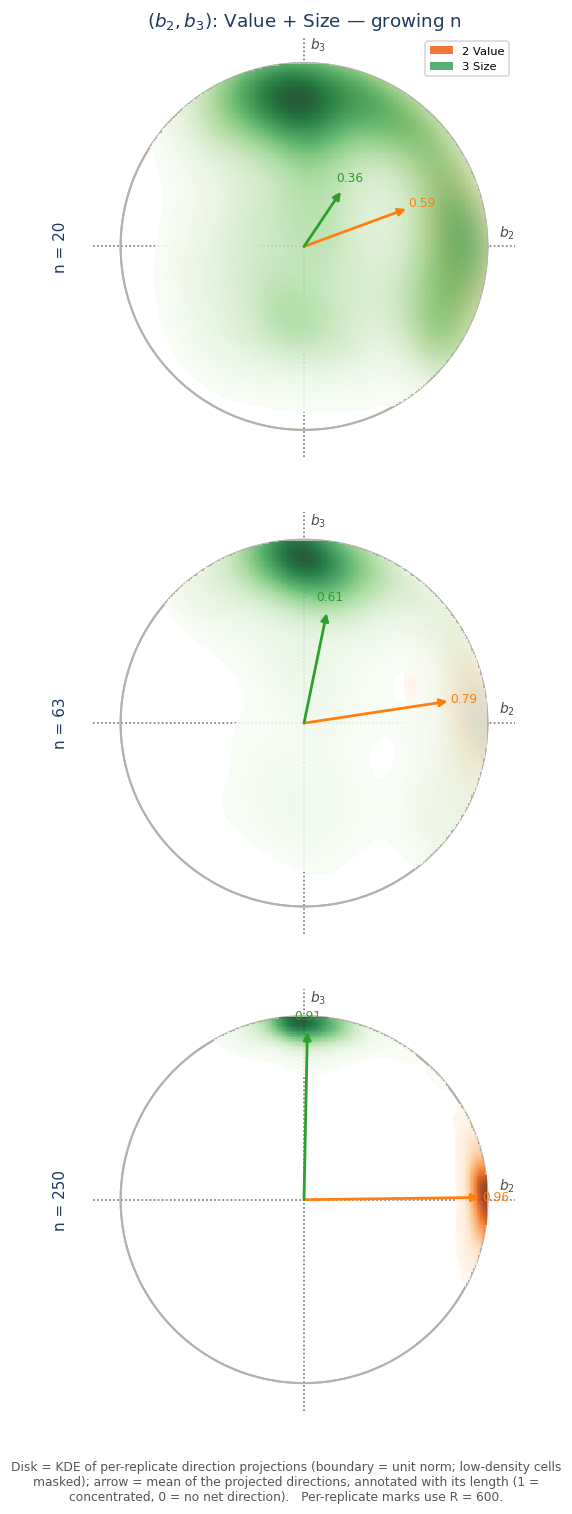

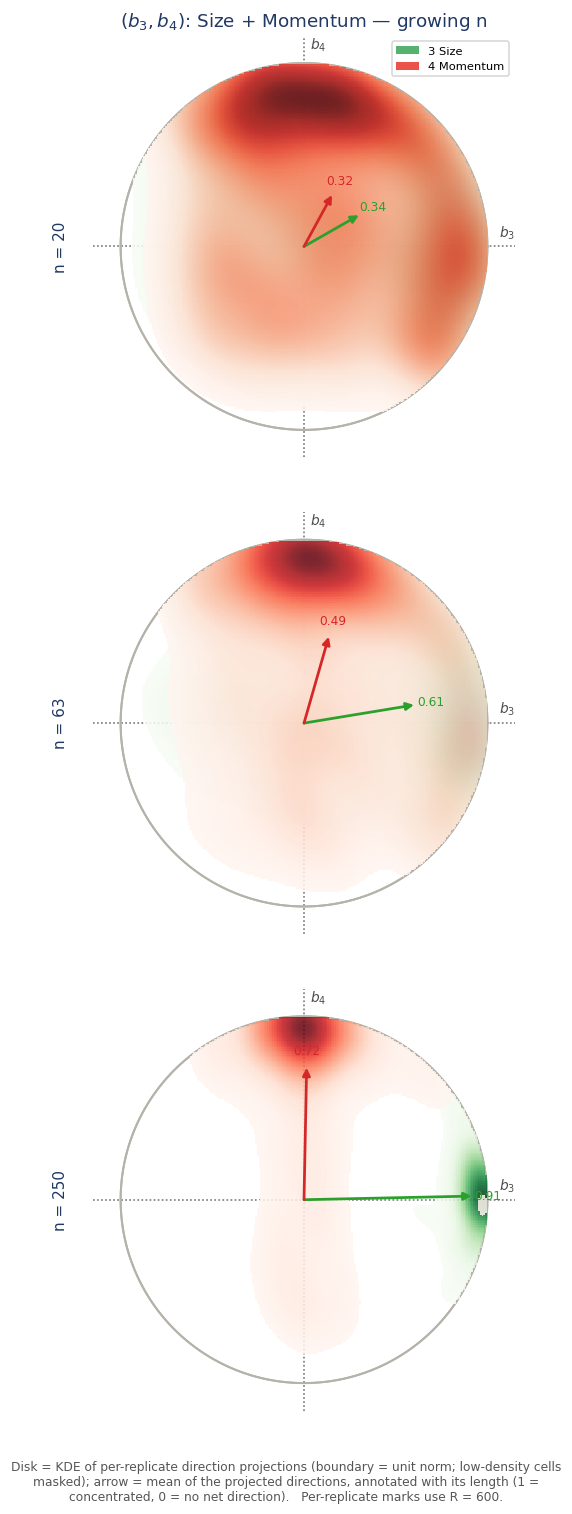

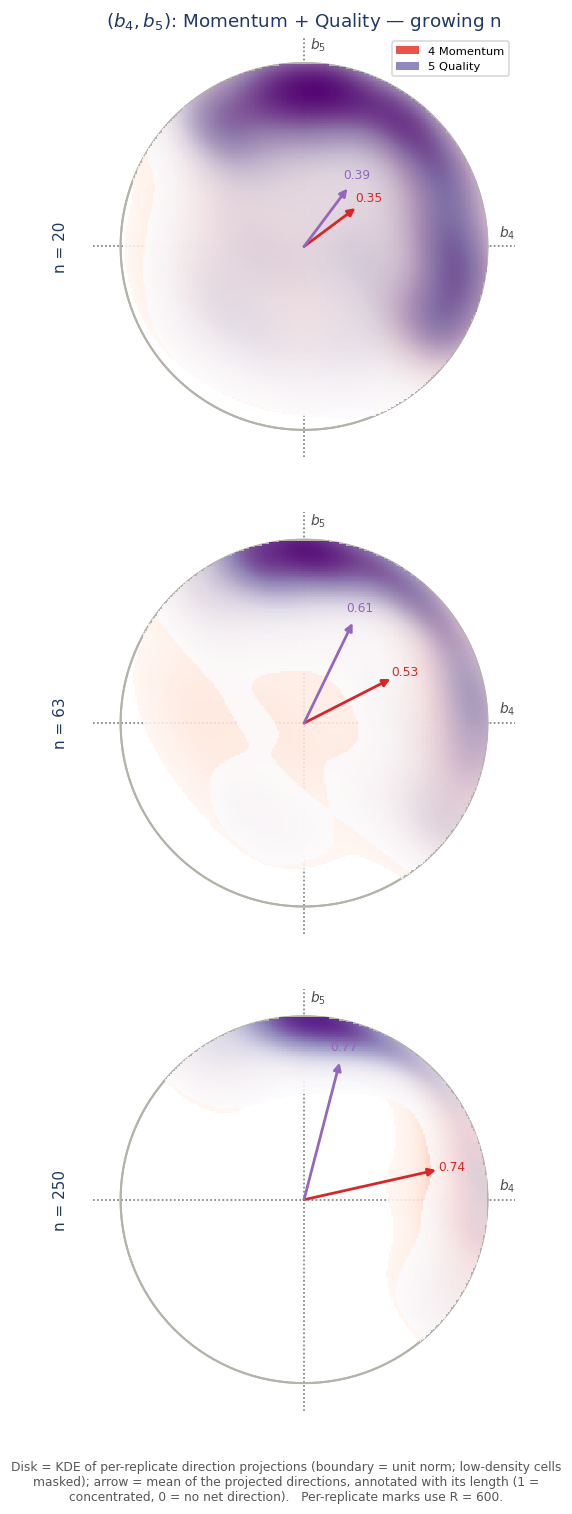

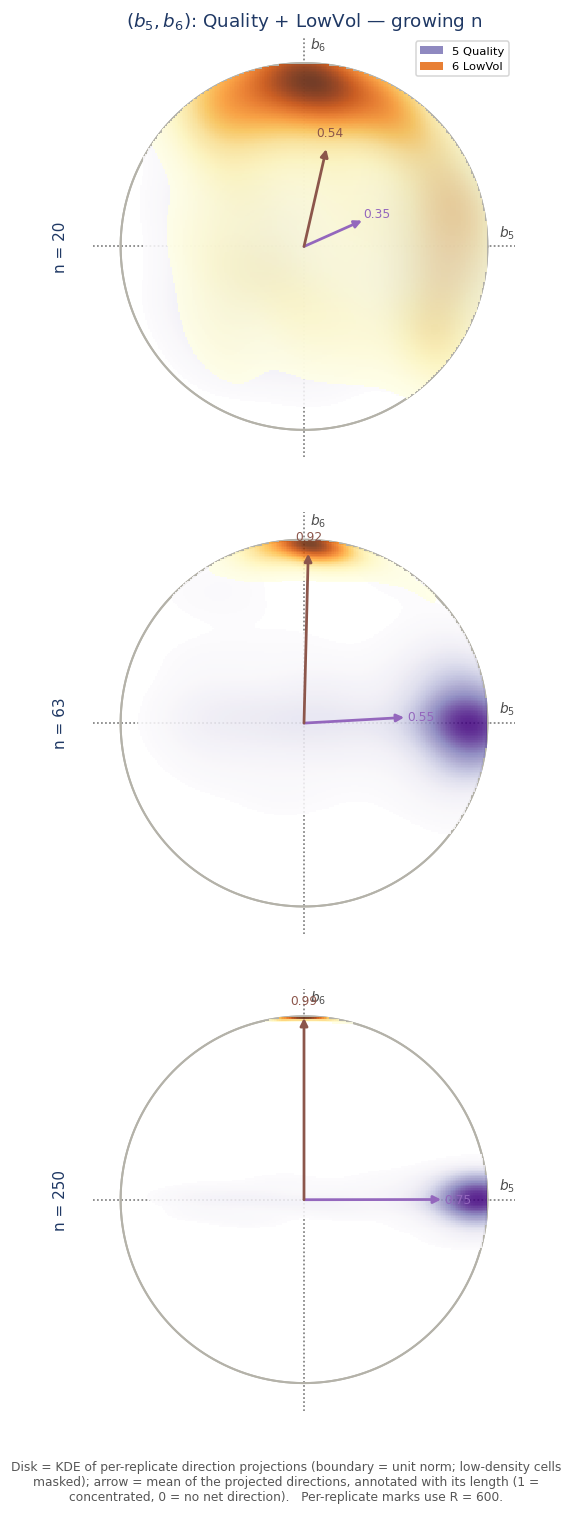

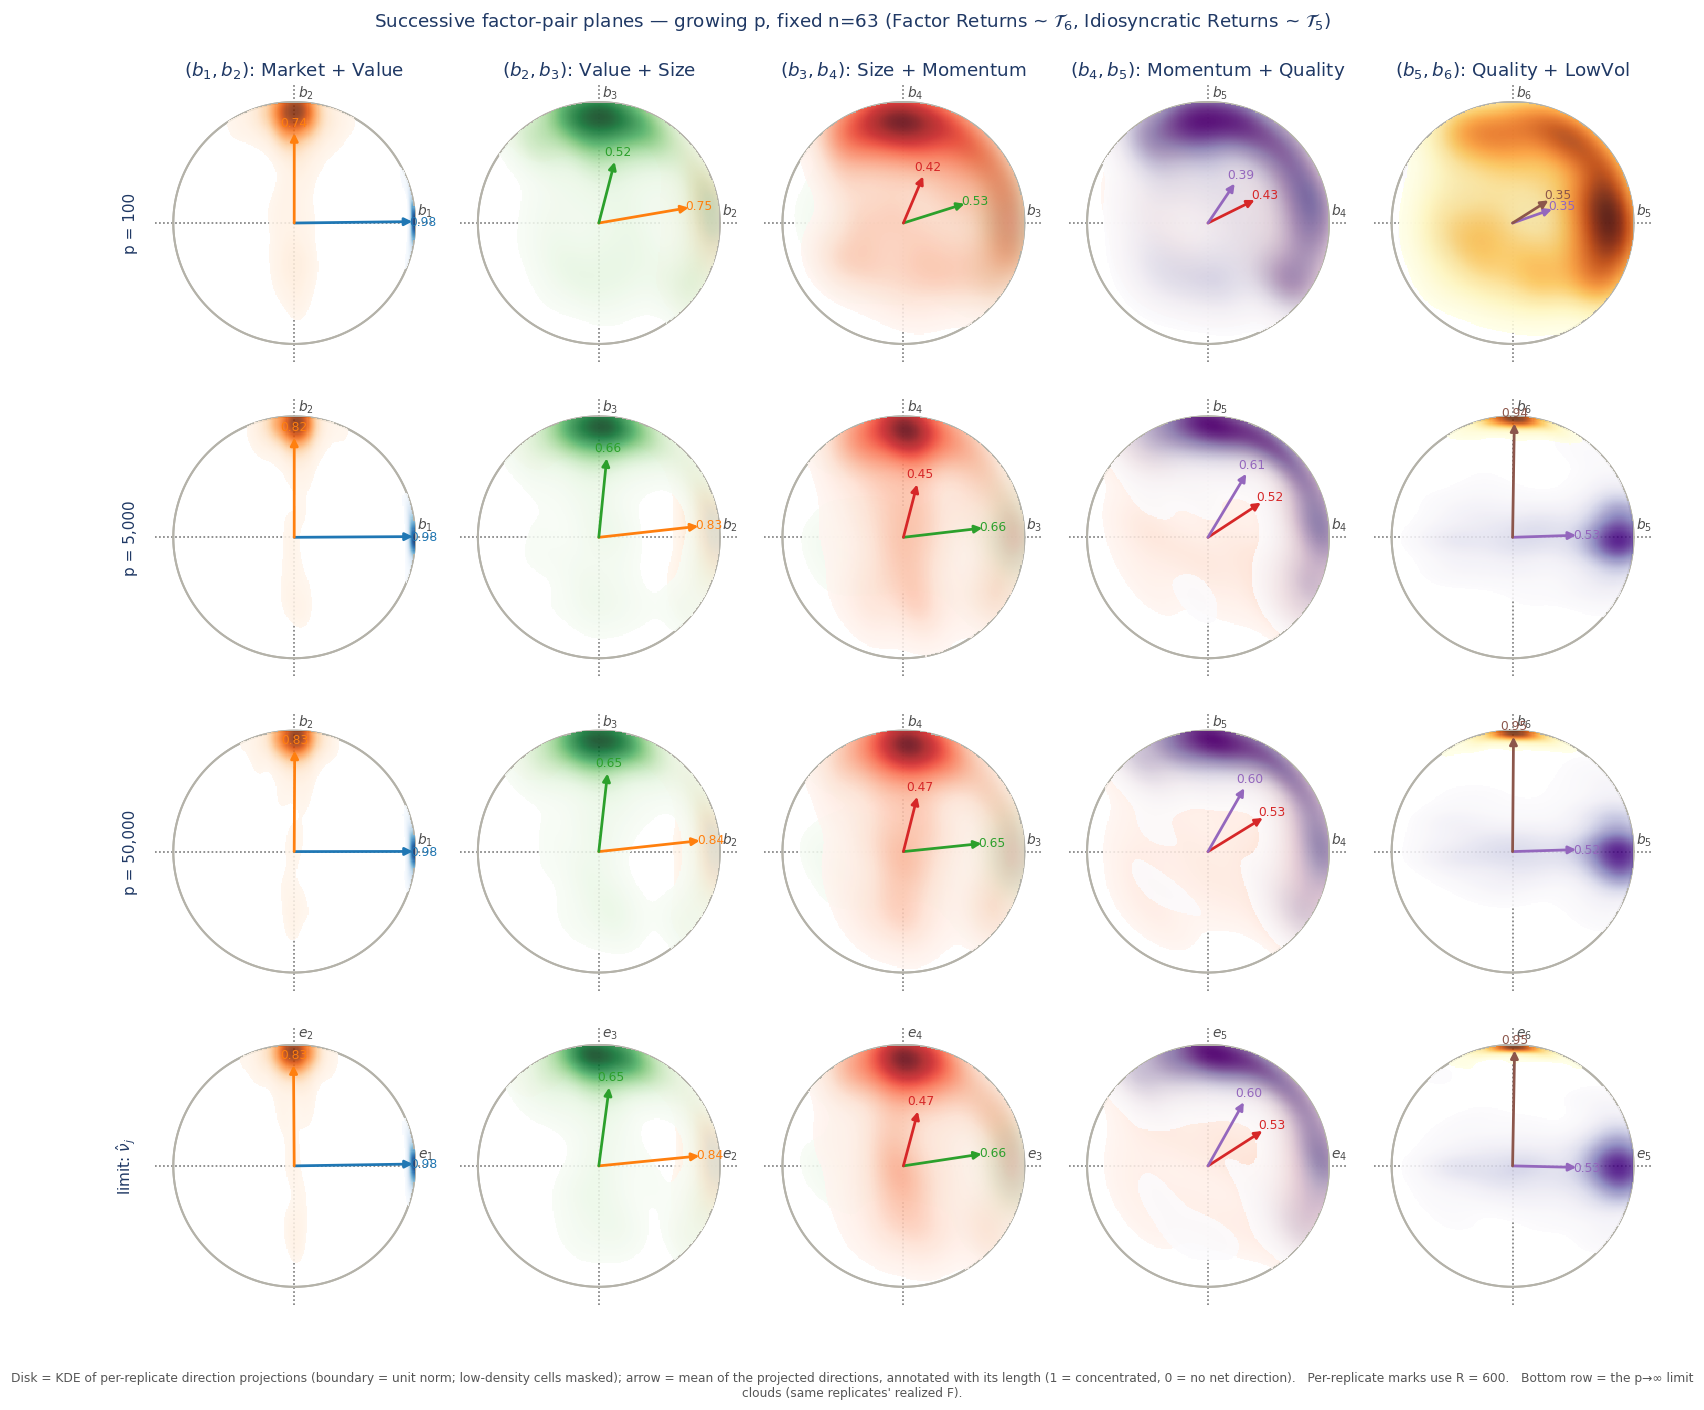

In [5]:
def pair_marks(f1, f2, at, *, coords="hd", axis_prefix="b"):
    """The two overlaid clouds + mean arrows for the (f1, f2) plane at one slice."""
    xc, yc = f"{coords}{f1}", f"{coords}{f2}"
    return [DiskDensity(xc, yc, factor=f1, at=at, mean_arrow=True,
                        label=f"{f1} {NAMES[f1 - 1]}",
                        labels=(rf"${axis_prefix}_{f1}$", rf"${axis_prefix}_{f2}$")),
            DiskDensity(xc, yc, factor=f2, at=at, mean_arrow=True,
                        label=f"{f2} {NAMES[f2 - 1]}")]


PAIRS = [(f1, f1 + 1) for f1 in range(1, K)]

# ── Growing n: one figure per pair (rows = n) ─────────────────────────────────
for f1, f2 in PAIRS:
    fig, _ = grid(
        df_n, "n", factors=[1],
        col_titles=[rf"$(b_{f1}, b_{f2})$: {NAMES[f1 - 1]} + {NAMES[f2 - 1]} — growing n"],
        rows=[Row(pair_marks(f1, f2, {"n": v}), ylabel=f"n = {v}", height=1.0)
              for v in (20, 63, 250)],
        sharey=False, figsize=(5.4, 14.0),
        formats=FIG_FORMATS, out_path=OUT_DIR / f"ex7_plane_b{f1}b{f2}")
    show(fig)

# ── Growing p: ONE figure — columns = pairs, rows = p values + the ν̂ limit ────
fig, _ = grid(
    df_p, "p", factors=list(range(1, K)),          # 5 layout columns, marks all pinned
    col_titles=[rf"$(b_{f1}, b_{f2})$: {NAMES[f1 - 1]} + {NAMES[f2 - 1]}"
                for f1, f2 in PAIRS],
    rows=[Row(cells=[pair_marks(f1, f2, {"p": v}) for f1, f2 in PAIRS],
              ylabel=f"p = {v:,}", height=1.0) for v in (100, 5000, 50000)]
         + [Row(cells=[pair_marks(f1, f2, {"p": 50000}, coords="nud", axis_prefix="e")
                       for f1, f2 in PAIRS],
                ylabel=r"limit: $\hat\nu_j$", height=1.0)],
    sharey=False, figsize=(15.5, 13.0), legend_row=None,
    suptitle=rf"Successive factor-pair planes — growing p, fixed n=63 {_TAILS}",
    caption_extra="Bottom row = the p→∞ limit clouds (same replicates' realized F).",
    formats=FIG_FORMATS, out_path=OUT_DIR / "ex7_planes_growing_p")
show(fig)


## Step 5b — each estimated factor against *all* factors successively

The pair planes above are each factor's **own** frame — a factor is only ever confronted
with its adjacent partner, so leakage into a non-adjacent axis is invisible (Quality's
short arrow in the $(b_5, b_6)$ plane had no visible cause *in that plane*: its lost mass
points at $b_4$).

This view transposes the question: **rows = estimated factors** $h_j$, **columns = all
successive planes** $(b_i, b_{i+1})$ — each row traces one estimated direction through
every 2-D window of the population frame. How to read row $j$:

* in a plane **containing** $b_j$: a healthy factor is a tight boundary cloud at its own
  axis;
* in a plane **not containing** $b_j$: a healthy factor sits at the **origin** (its mass
  is elsewhere); any boundary mass here is leakage into factors it should have nothing to
  do with;
* the mean arrow's length in each window is the share of direction pointing into that
  plane — reading across a row localizes *where* a factor's identity leaks.

The 6×6 **mean-share matrix** below (mean of $\mathrm{hb}_i^2/\lVert\Pi h_j\rVert^2$,
rows = population factor $i$, columns = estimated $j$; columns sum to 100%) is the same
information as numbers — a confusion matrix for factor identification.


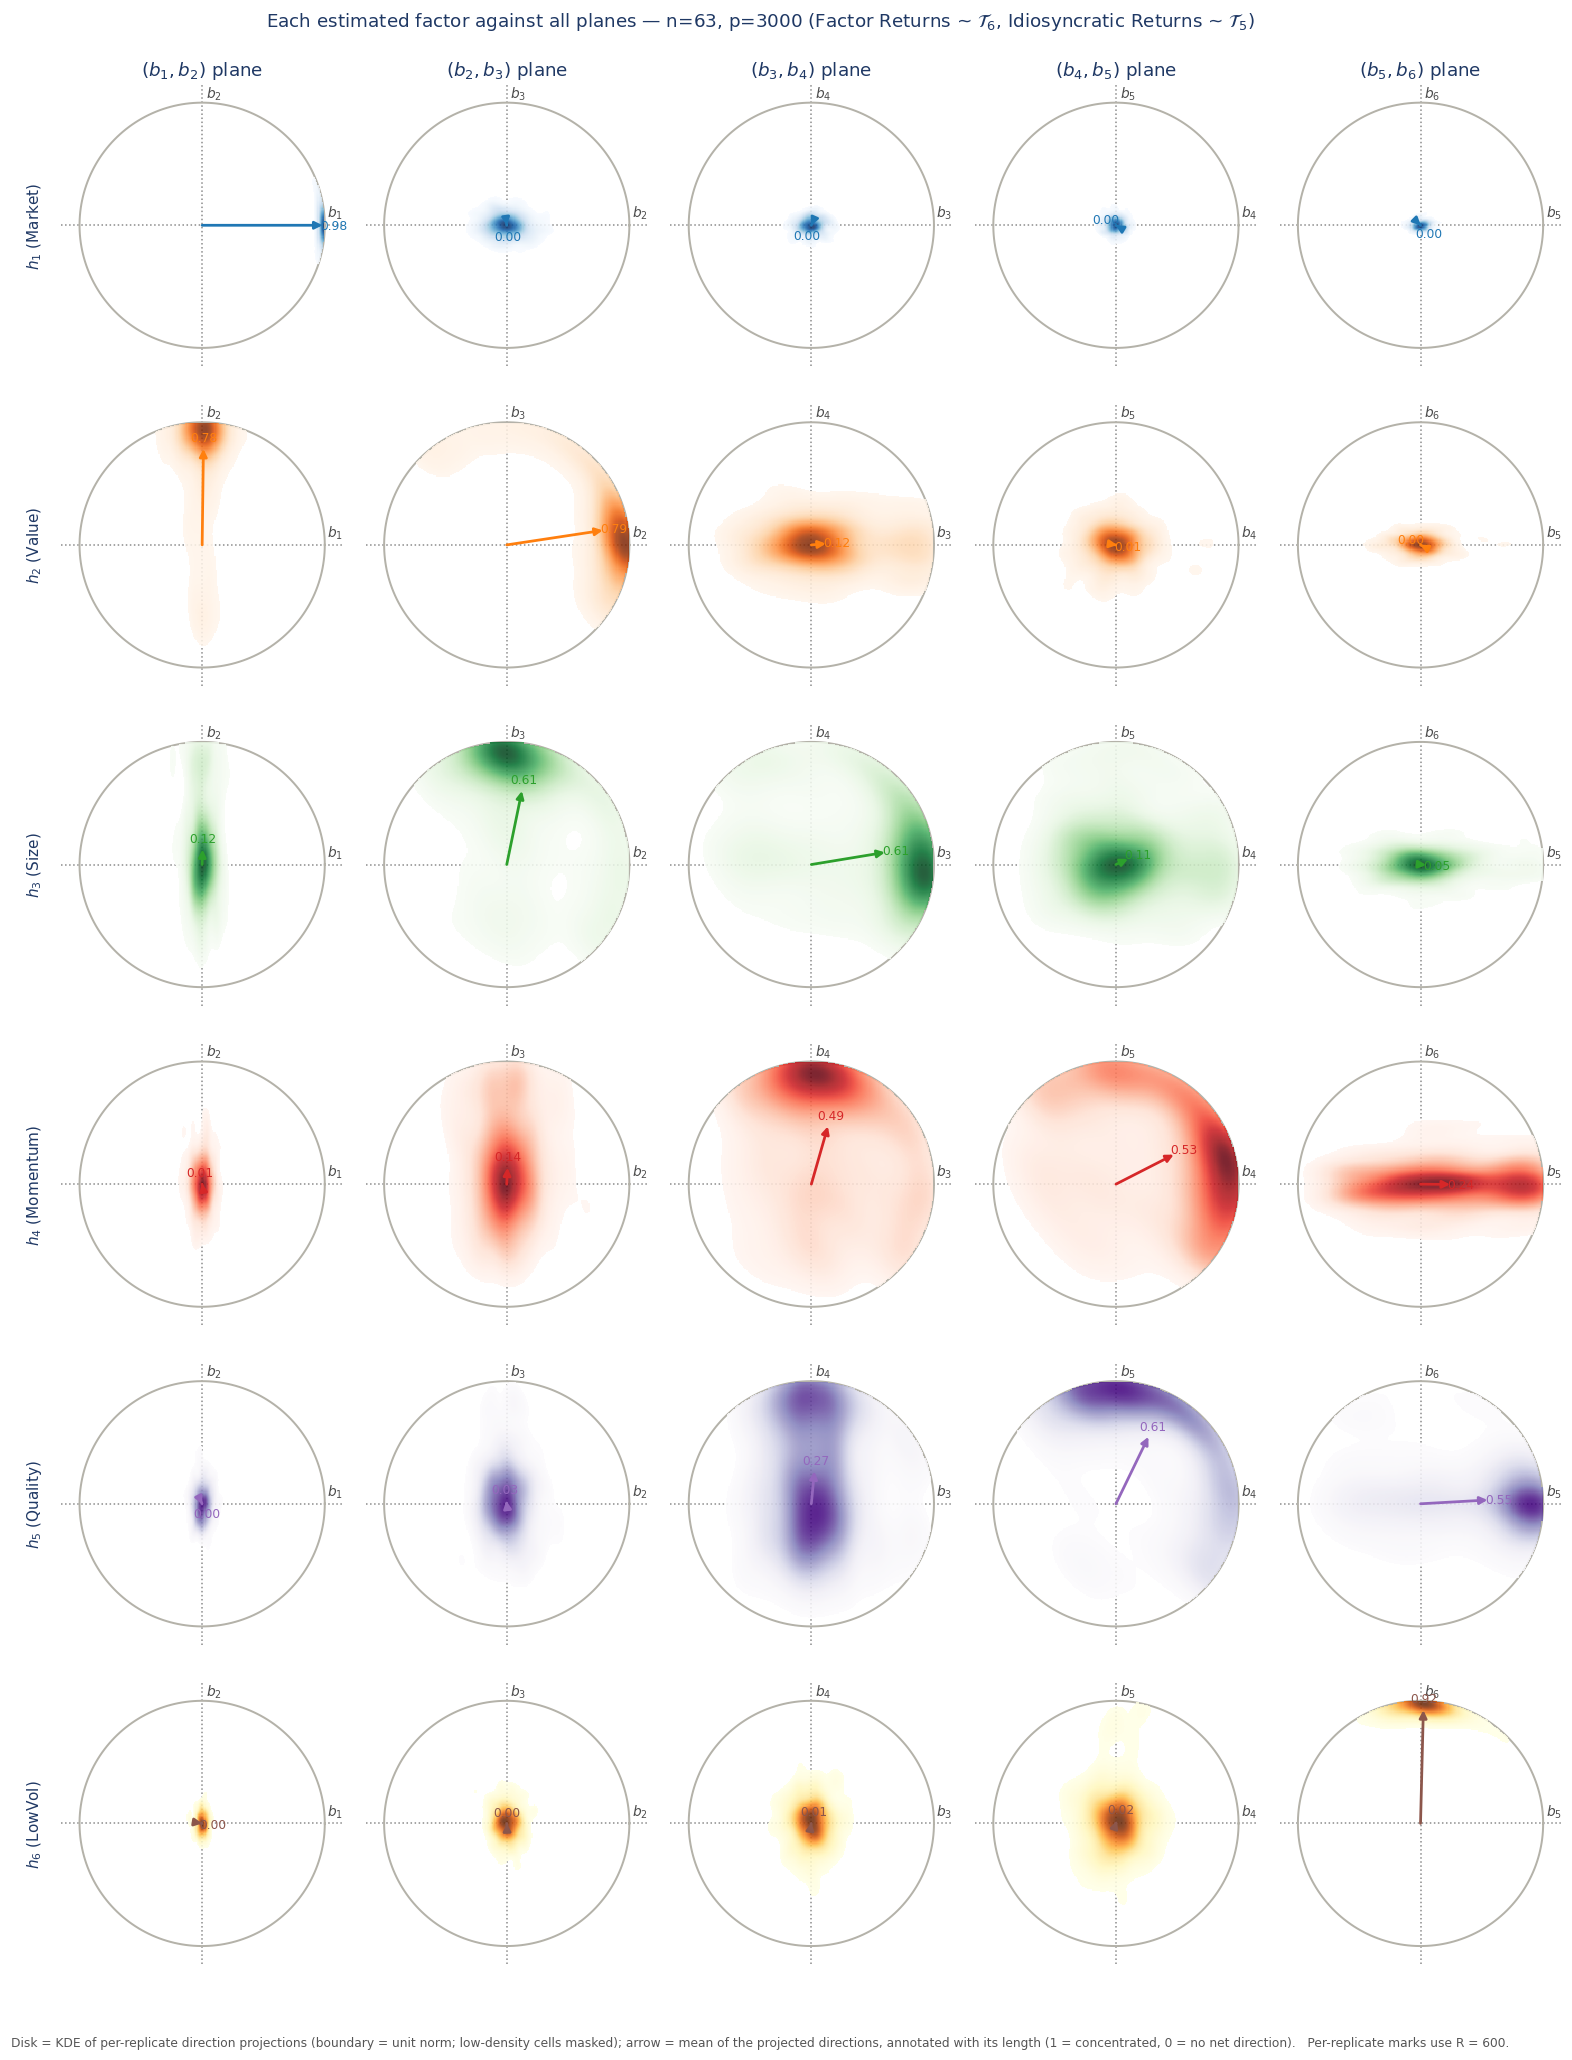

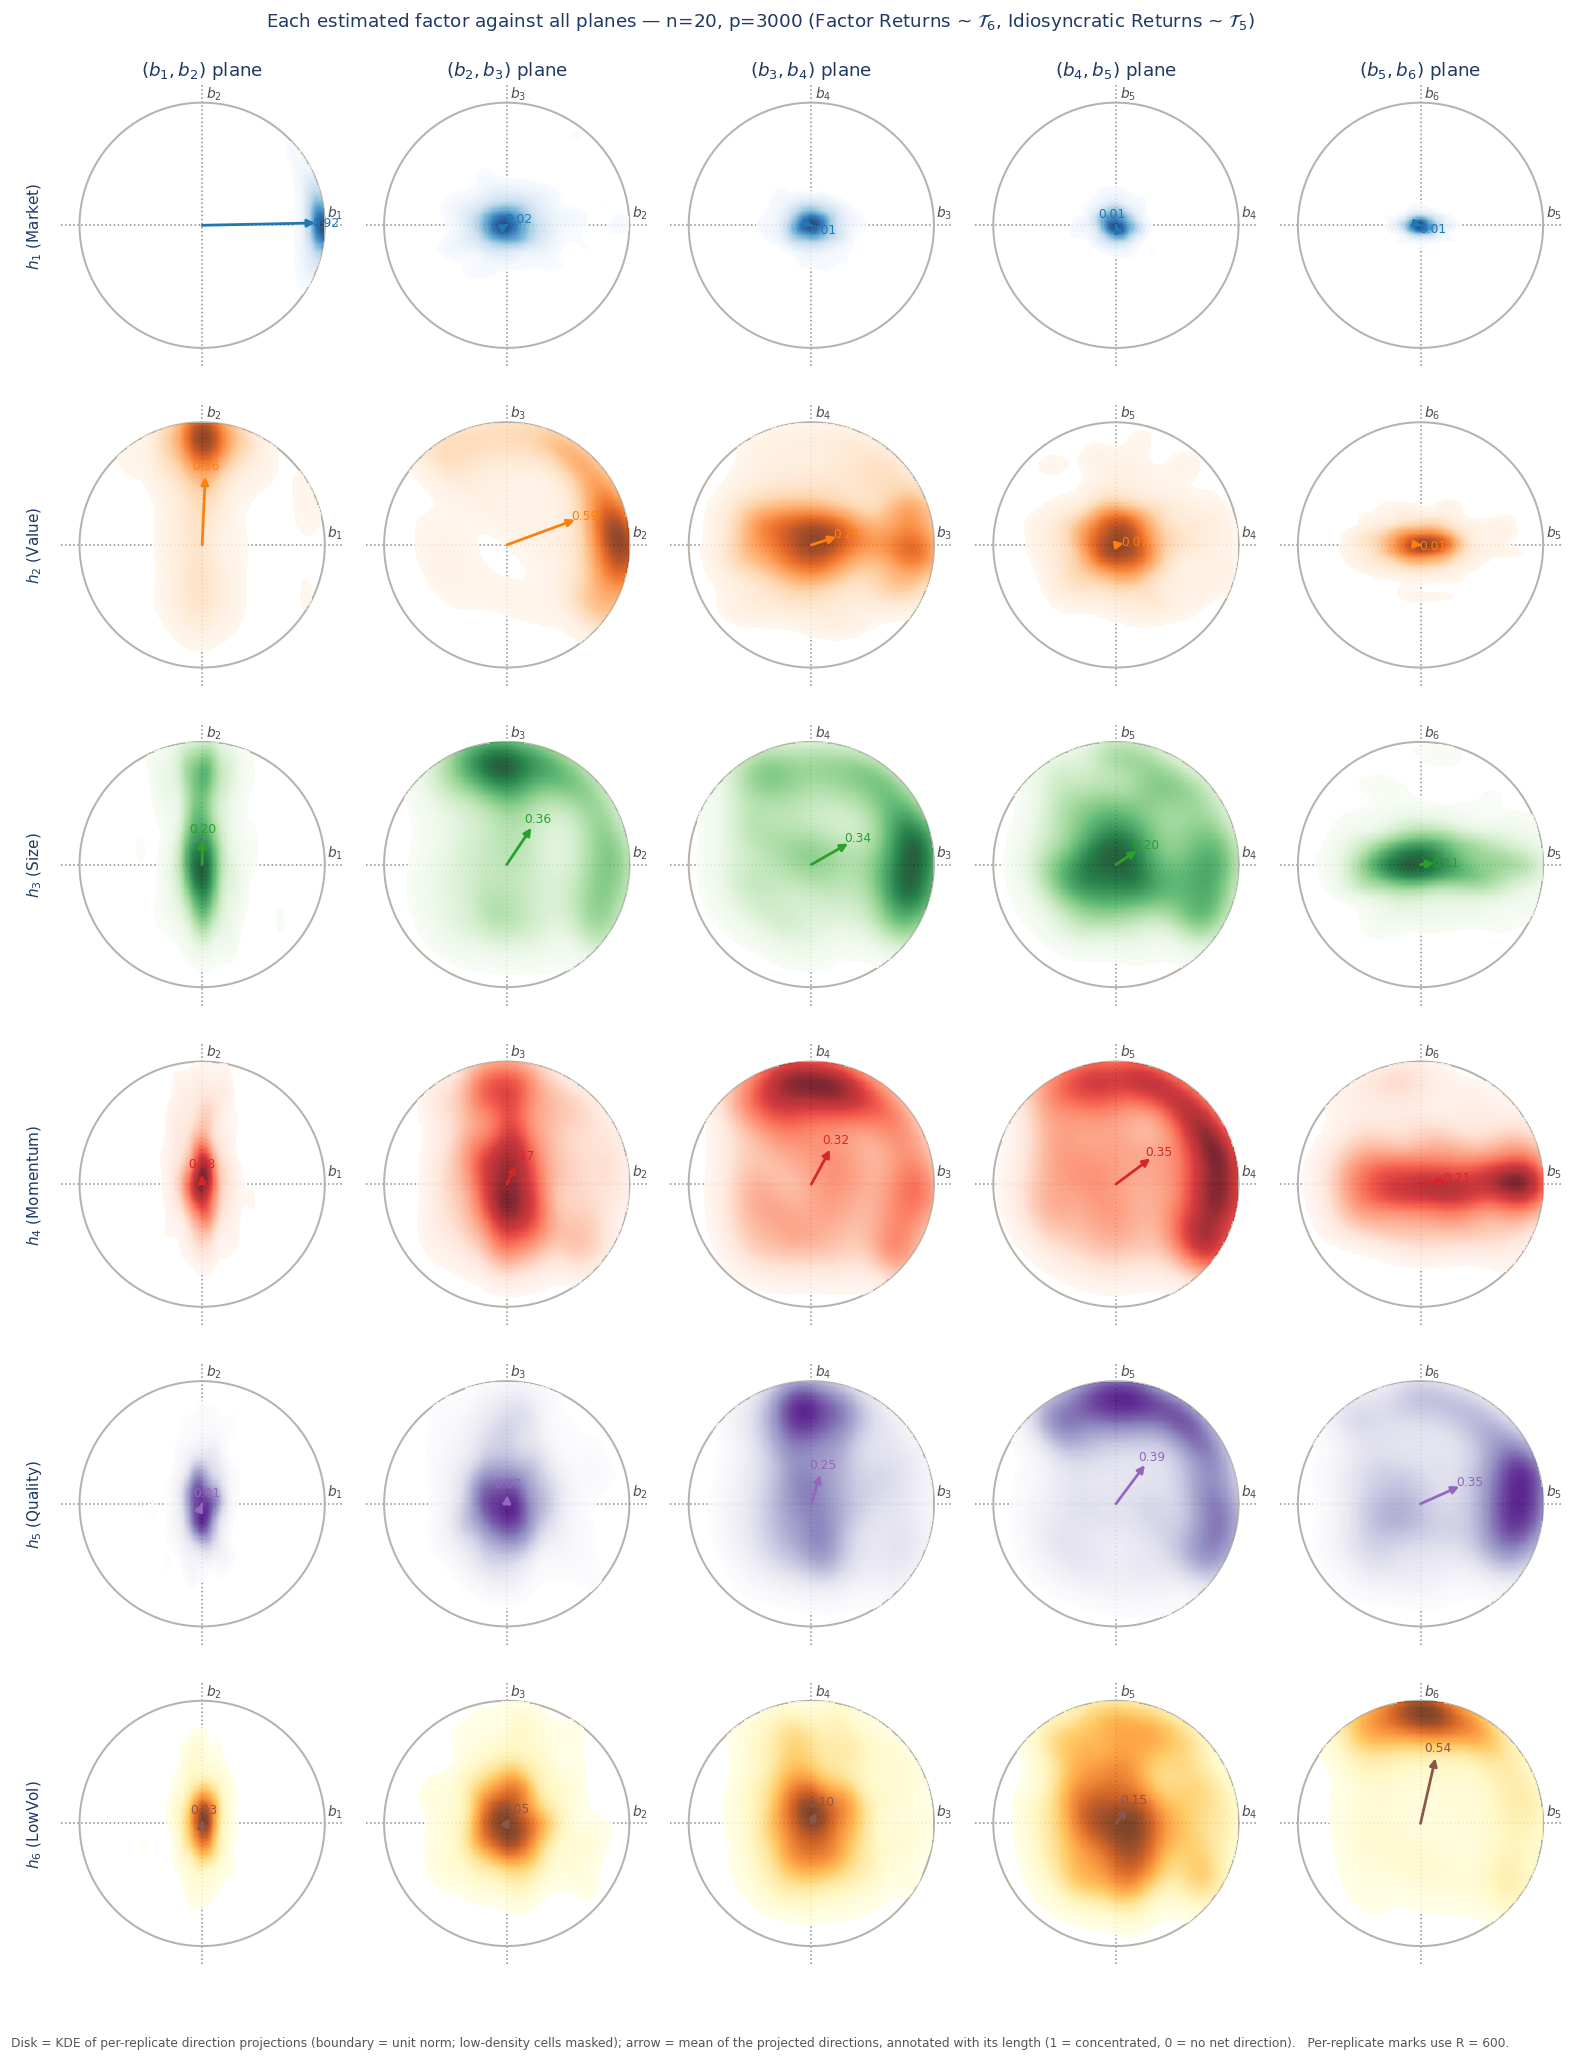

mean in-subspace mass share (%), n=63:


,h1 Market,h2 Value,h3 Size,h4 Momentum,h5 Quality,h6 LowVol
b1 Market,97.0,1.7,0.6,0.4,0.3,0.1
b2 Value,1.8,76.3,16.0,3.7,1.9,0.6
b3 Size,0.6,15.7,58.7,17.1,6.8,1.3
b4 Momentum,0.3,3.5,15.1,48.1,30.2,3.0
b5 Quality,0.3,2.3,8.6,28.5,55.1,5.7
b6 LowVol,0.1,0.5,1.1,2.3,5.8,89.3


mean in-subspace mass share (%), n=20:


,h1 Market,h2 Value,h3 Size,h4 Momentum,h5 Quality,h6 LowVol
b1 Market,89.4,5.4,2.3,1.4,1.2,1.2
b2 Value,5.2,53.3,22.8,10.3,6.0,5.9
b3 Size,2.5,24.5,33.7,21.7,12.8,8.9
b4 Momentum,1.5,9.2,20.8,31.8,27.0,14.3
b5 Quality,1.1,6.0,16.4,26.8,33.9,19.2
b6 LowVol,0.3,1.5,4.0,8.1,19.0,50.6


In [6]:
def factor_vs_all(df, at, at_label, out_stem):
    """6×5 grid: rows = estimated factors h_j, columns = successive (b_i, b_{i+1}) planes."""
    fig, _ = grid(
        df, list(at.keys())[0], factors=list(range(1, K)),   # 5 layout columns
        col_titles=[rf"$(b_{i}, b_{i + 1})$ plane" for i, _ in PAIRS],
        rows=[Row(cells=[[DiskDensity(f"hd{i}", f"hd{i + 1}", factor=j, at=at,
                                      mean_arrow=True,
                                      labels=(rf"$b_{i}$", rf"$b_{i + 1}$"))]
                         for i, _ in PAIRS],
                  ylabel=rf"$h_{j}$ ({NAMES[j - 1]})", height=1.0)
              for j in range(1, K + 1)],
        sharey=False, figsize=(15.5, 19.0), legend_row=None,
        suptitle=rf"Each estimated factor against all planes — {at_label} {_TAILS}",
        formats=FIG_FORMATS, out_path=OUT_DIR / out_stem)
    show(fig)


factor_vs_all(df_n, {"n": 63}, "n=63, p=3000", "ex7_factor_vs_all_n63")
factor_vs_all(df_n, {"n": 20}, "n=20, p=3000", "ex7_factor_vs_all_n20")


def share_matrix(df, at):
    """Mean in-subspace mass share: rows = population b_i, cols = estimated h_j (% sums to 100)."""
    s = df
    for c, v in at.items():
        s = s[s[c] == v]
    C2 = s[HB].to_numpy() ** 2
    C2 = C2 / C2.sum(axis=1, keepdims=True)
    out = pd.DataFrame(
        {f"h{j} {NAMES[j - 1]}": 100 * C2[s["j"].to_numpy() == j].mean(axis=0)
         for j in range(1, K + 1)},
        index=[f"b{i} {NAMES[i - 1]}" for i in range(1, K + 1)])
    return out.round(1)


print("mean in-subspace mass share (%), n=63:")
display(share_matrix(df_n, {"n": 63}))
print("mean in-subspace mass share (%), n=20:")
display(share_matrix(df_n, {"n": 20}))


## Step 6 — the numbers

In [7]:
def tail_table(df, key):
    t = (df.groupby([key, "j"])["sin2_in"]
           .agg(median="median", q3=lambda s: s.quantile(0.75),
                p95=lambda s: s.quantile(0.95),
                frac_gt_half=lambda s: (s > 0.5).mean())
           .round(4)
           .reset_index())
    t.insert(2, "name", t["j"].map(lambda j: NAMES[j - 1]))
    return t

print("growing n (p=3000):")
display(tail_table(df_n, "n"))
print("growing p (n=63):")
display(tail_table(df_p, "p"))


growing n (p=3000):


,n,j,name,median,q3,p95,frac_gt_half
0,20,1,Market,0.0556,0.1188,0.3767,0.0367
1,20,2,Value,0.3878,0.7717,0.9863,0.4267
2,20,3,Size,0.7251,0.9377,0.9977,0.6817
3,20,4,Momentum,0.7423,0.9519,0.9974,0.7283
4,20,5,Quality,0.7234,0.9366,0.9979,0.6983
5,20,6,LowVol,0.4335,0.8136,0.9893,0.4433
6,63,1,Market,0.0176,0.0348,0.0837,0.0050
7,63,2,Value,0.1201,0.2959,0.9005,0.1717
8,63,3,Size,0.3165,0.6662,0.9809,0.3567
9,63,4,Momentum,0.4989,0.8564,0.9944,0.5000


growing p (n=63):


,p,j,name,median,q3,p95,frac_gt_half
0,100,1,Market,0.0259,0.0480,0.1374,0.0033
1,100,2,Value,0.1823,0.4020,0.9476,0.1900
2,100,3,Size,0.4827,0.8074,0.9905,0.4900
3,100,4,Momentum,0.6661,0.9050,0.9933,0.6250
4,100,5,Quality,0.7000,0.9077,0.9949,0.6533
5,100,6,LowVol,0.8356,0.9656,0.9985,0.8117
6,500,1,Market,0.0204,0.0369,0.0927,0.0017
7,500,2,Value,0.1110,0.2535,0.8613,0.1183
8,500,3,Size,0.2891,0.6531,0.9830,0.3217
9,500,4,Momentum,0.5635,0.8634,0.9921,0.5400


---
## Change log

- **2026-08-03**: new notebook — the ex-6 pipeline on a stylized six-factor model
  (Market/Value/Size/Momentum/Quality/LowVol vols, adjacent spike gaps from 3.2× down to
  1.17×). Records the full 6-vector projection coordinates per replicate (classes carried
  from ex-6, k-generic), n-sweep at p=3000, R=600, cached to `ex7_df_n.parquet`. Figures:
  six-factor scalar overview + the five successive factor-pair plane disks with overlaid
  clouds and mean arrows, factor coloring consistent with the theme (1 blue … 6 brown).
  Figures → `nb_outputs/ex-7_six_factor/`.
- **2026-08-03 (b)**: added the growing-p sweep at fixed n=63 (`ex7_df_p.parquet`, same
  seed/R): scalar overview across p, and the growing-p plane disks — now a single 4×5
  figure (columns = pairs, rows = p values + the $\hat\nu_j$ limit clouds) via
  `Row(cells=...)`.
- **2026-08-03 (c)**: Step 5b — each estimated factor against **all** planes: 6×5 grids
  (rows = $h_j$, columns = successive $(b_i, b_{i+1})$ windows) at n=63 and n=20, plus the
  6×6 mean in-subspace mass-share matrices (a confusion matrix for factor identification;
  near-tridiagonal — leakage is adjacency-driven). At n=63 Momentum keeps only 48% of its
  in-subspace mass on its own axis; at n=20 the Size/Momentum/Quality block is ≈⅓ each.
